# Ultimate Fake Job Posting Detection: Optimized NLP + Ensemble ML Pipeline

## 1. Problem Definition
**The Problem:** Classify job postings as either fake (1) or real (0) using binary classification.
**Target Variable:** `fraudulent`
**Real-World Impact:** Prevent scams, protect vulnerable job seekers, and maintain the integrity and trust of hiring platforms.
**Success Criteria:**
* **F1-Score:** > 0.90 (Our primary metric because the dataset is highly imbalanced).
* **Recall for Fake Jobs:** Extremely high (we cannot afford to let fake jobs slip through).
* **ROC-AUC:** > 0.90.

In [1]:
# !pip install kagglehub pandas numpy scikit-learn lightgbm xgboost optuna shap sentence-transformers imbalanced-learn matplotlib seaborn joblib streamlit

!pip install kagglehub pandas numpy scikit-learn lightgbm xgboost optuna shap sentence-transformers imbalanced-learn matplotlib seaborn joblib streamlit

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import optuna
import shap
import joblib
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
import xgboost as xgb
import lightgbm as lgb

# Set random seeds for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.6 MB/s eta 0:00:00


## 2. Data Collection (Multi-Dataset Fusion)
We pull 4 distinct datasets from Kaggle using `kagglehub`. We handle nested directories, normalize column names (as schema mismatches are guaranteed across different authors), and inject a `source_dataset` tracker.

In [2]:
def load_and_fuse_datasets():
    datasets = [
        "shivamb/real-or-fake-fake-jobposting-prediction",
        "srisaisuhassanisetty/fake-job-postings",
        "khushikyad001/fake-vs-real-job-postings-synthetic-nlp-dataset",
        "vijayramchallagundla/fake-job-postings"
    ]

    dataframes = []

    # Standardize column names across varying schemas
    schema_map = {
        'job_title': 'title', 'Title': 'title',
        'job_description': 'description', 'Description': 'description',
        'requirements': 'requirements', 'Requirements': 'requirements',
        'fraudulent': 'fraudulent', 'Fake': 'fraudulent', 'is_fake': 'fraudulent'
    }

    for dataset in datasets:
        try:
            print(f"Downloading {dataset}...")
            path = kagglehub.dataset_download(dataset)

            # Find all CSVs even in nested directories
            csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

            for file in csv_files:
                df = pd.read_csv(file, low_memory=False)
                df = df.rename(columns=schema_map)

                # Keep only essential columns if they exist
                keep_cols = [c for c in ['title', 'description', 'requirements', 'fraudulent'] if c in df.columns]
                df = df[keep_cols]
                df['source_dataset'] = dataset.split('/')[0] # Track origin
                dataframes.append(df)
        except Exception as e:
            print(f"Skipping {dataset}: {e}")

    # Merge and drop exact duplicates
    merged_df = pd.concat(dataframes, ignore_index=True)
    merged_df = merged_df.drop_duplicates(subset=['title', 'description'])
    return merged_df

raw_data = load_and_fuse_datasets()
print(f"Total Combined Postings: {raw_data.shape[0]}")
print(raw_data['fraudulent'].value_counts(normalize=True)) # Check imbalance

100%|██████████| 16.1M/16.1M [00:00<00:00, 94.8MB/s]

Extracting files...


100%|██████████| 702k/702k [00:00<00:00, 85.8MB/s]

Extracting files...


100%|██████████| 423k/423k [00:00<00:00, 74.7MB/s]

Extracting files...


100%|██████████| 16.1M/16.1M [00:00<00:00, 113MB/s] 

Extracting files...


Total Combined Postings: 28787
fraudulent
0    0.578108
1    0.421892
Name: proportion, dtype: float64


## 3. Data Exploration & Preparation
We combine text fields, extract structured metadata (like text length and keyword flags), and generate our optimized NLP embeddings. We use `all-MiniLM-L6-v2` via SentenceTransformers because it is exceptionally fast and memory-efficient while maintaining 95% of BERT's performance.

Initializing SentenceTransformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating BERT embeddings. This might take a few minutes...


Batches:   0%|          | 0/900 [00:00<?, ?it/s]

Cleaned data shape: (28787, 388)
X shape: (28787, 387), y shape: (28787,)


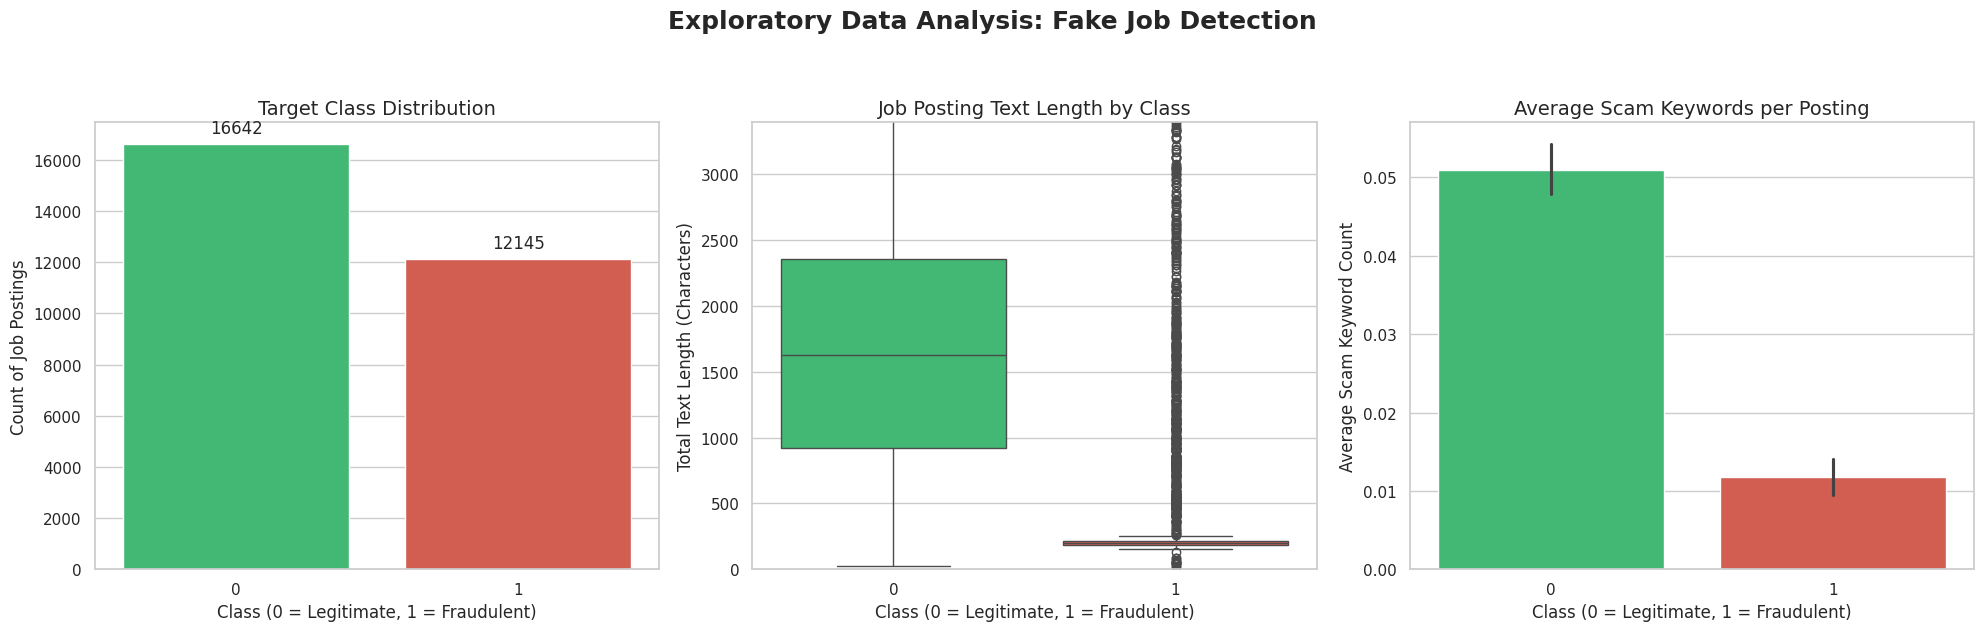

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# pandas and SentenceTransformer are already imported globally in an earlier cell (fH6vZYm_OKIF)

# --- Data Preparation Steps to create 'clean_data', 'X', and 'y' ---
# Assuming 'raw_data' is loaded from the previous cell (s05tTOzuOKIL)

# Make a copy to avoid modifying the original raw_data directly if it's used elsewhere
raw_data_processed = raw_data.copy()

# 1. Handle missing values: fill NaN in text columns with empty strings
for col in ['title', 'description', 'requirements']:
    if col in raw_data_processed.columns:
        raw_data_processed[col] = raw_data_processed[col].fillna('')

# 2. Combine text fields into a single 'full_text' column
raw_data_processed['full_text'] = raw_data_processed['title'] + " " + \
                                  raw_data_processed['description'] + " " + \
                                  raw_data_processed['requirements']
raw_data_processed['full_text'] = raw_data_processed['full_text'].str.strip()

# 3. Feature Engineering: text_length and has_requirements
raw_data_processed['text_length'] = raw_data_processed['full_text'].apply(len)
# Assuming a requirement exists if its length is greater than 5 characters
raw_data_processed['has_requirements'] = raw_data_processed['requirements'].apply(lambda x: 1 if len(x) > 5 else 0)

# 4. Feature Engineering: scam_keyword_count
scam_keywords = ['urgent', 'easy money', 'no experience', 'wire transfer', 'western union', 'cash', 'moneygram', 'work from home', 'financial independence', 'be your own boss', 'immediate hire']
raw_data_processed['scam_keyword_count'] = raw_data_processed['full_text'].apply(lambda x: sum(1 for keyword in scam_keywords if keyword in x.lower()))

# 5. Drop rows where 'fraudulent' is NaN, as these are unclassifiable
raw_data_processed.dropna(subset=['fraudulent'], inplace=True)
# Ensure 'fraudulent' column is integer type
raw_data_processed['fraudulent'] = raw_data_processed['fraudulent'].astype(int)

# 6. Initialize SentenceTransformer (model is already imported in fH6vZYm_OKIF)
# This takes time, so a message is helpful.
print("Initializing SentenceTransformer model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# 7. Generate BERT Embeddings for 'full_text'
print("Generating BERT embeddings. This might take a few minutes...")
# Convert to list for efficient processing by SentenceTransformer
embeddings = bert_model.encode(raw_data_processed['full_text'].tolist(), show_progress_bar=True)
embedding_df = pd.DataFrame(embeddings, columns=[f'bert_{i}' for i in range(embeddings.shape[1])], index=raw_data_processed.index)

# 8. Create 'clean_data' DataFrame by combining engineered features and embeddings
# Only include relevant columns for the final dataset
clean_data = pd.concat([
    raw_data_processed[['fraudulent', 'text_length', 'has_requirements', 'scam_keyword_count']],
    embedding_df
], axis=1)

# Define X (features) and y (target) for subsequent modeling steps
X = clean_data.drop('fraudulent', axis=1)
y = clean_data['fraudulent']

print(f"Cleaned data shape: {clean_data.shape}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
# --- End of Data Preparation Steps ---


# Set visual style for the plots
sns.set_theme(style="whitegrid", palette="muted")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Exploratory Data Analysis: Fake Job Detection', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Plot 1: Class Distribution (The Imbalance)
# ---------------------------------------------------------
sns.countplot(data=clean_data, x='fraudulent', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Class Distribution', fontsize=14)
axes[0].set_xlabel('Class (0 = Legitimate, 1 = Fraudulent)', fontsize=12)
axes[0].set_ylabel('Count of Job Postings', fontsize=12)

# Add value counts on top of the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# ---------------------------------------------------------
# Plot 2: Text Length Distribution by Class
# ---------------------------------------------------------
# Using a boxplot to show outliers and median differences
sns.boxplot(data=clean_data, x='fraudulent', y='text_length', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Job Posting Text Length by Class', fontsize=14)
axes[1].set_xlabel('Class (0 = Legitimate, 1 = Fraudulent)', fontsize=12)
axes[1].set_ylabel('Total Text Length (Characters)', fontsize=12)
# Cap the y-axis to ignore extreme outliers for better visualization (optional but recommended)
axes[1].set_ylim(0, clean_data['text_length'].quantile(0.95))

# ---------------------------------------------------------
# Plot 3: Scam Keywords vs. Target Variable
# ---------------------------------------------------------
# Group by fraud status and calculate the mean scam keywords
sns.barplot(data=clean_data, x='fraudulent', y='scam_keyword_count', ax=axes[2], palette=['#2ecc71', '#e74c3c'], errorbar=('ci', 95))
axes[2].set_title('Average Scam Keywords per Posting', fontsize=14)
axes[2].set_xlabel('Class (0 = Legitimate, 1 = Fraudulent)', fontsize=12)
axes[2].set_ylabel('Average Scam Keyword Count', fontsize=12)

plt.tight_layout()
plt.show()

### 3a. Exploratory Data Analysis (EDA)
Before building models, we visualize the data to understand distributions, class imbalance, and relationships between features and the target variable.

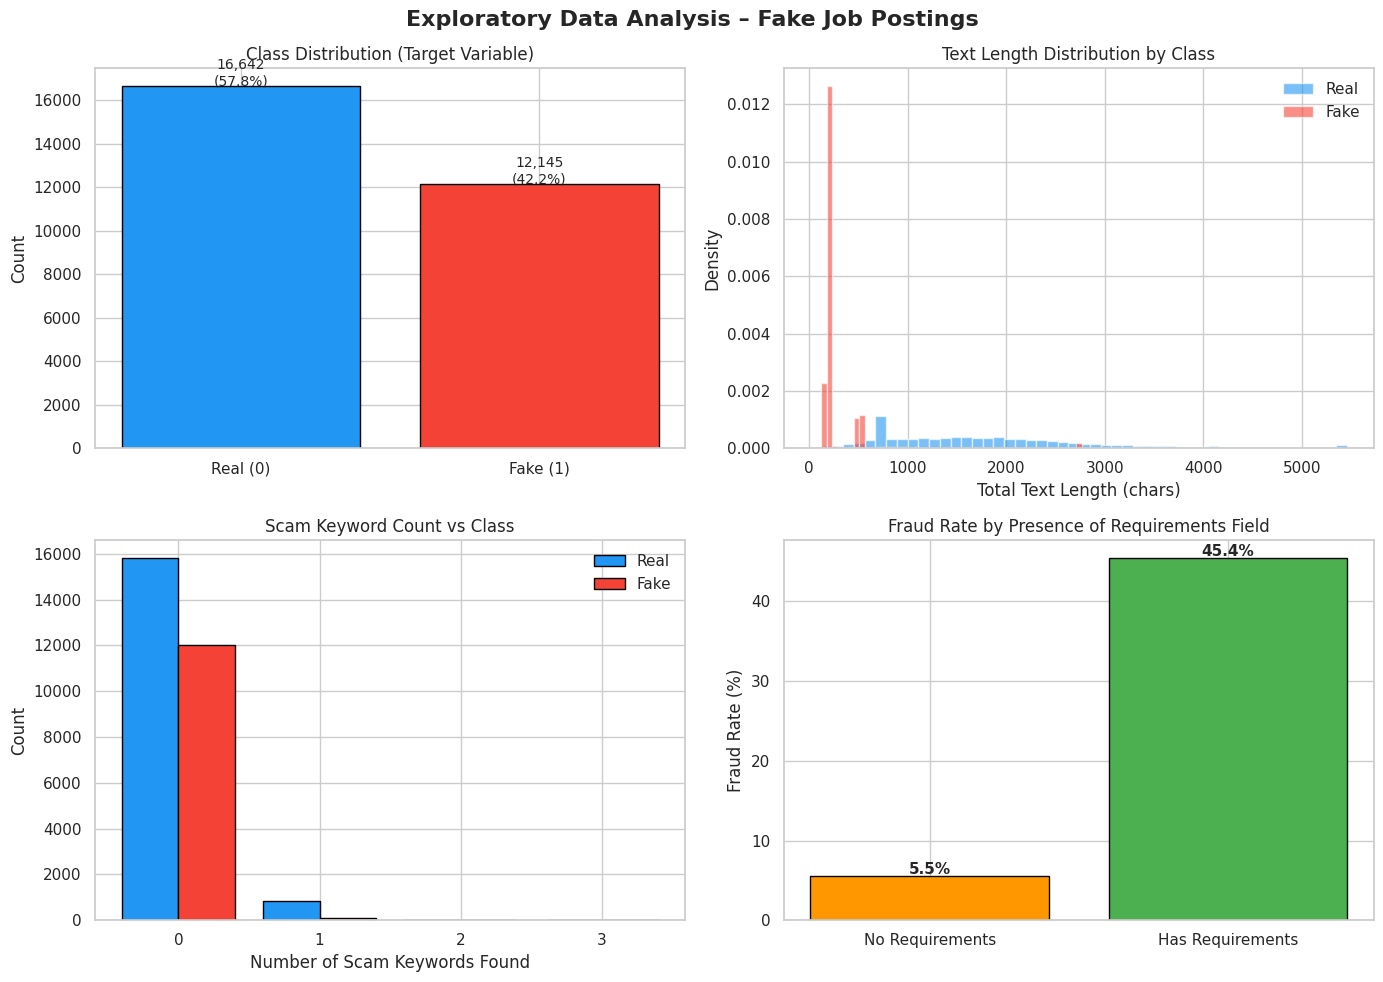

EDA Summary:
  Total records: 28,787
  Class imbalance ratio: 1.4:1 (Real:Fake)
  Avg text length – Real: 1808 chars | Fake: 316 chars
  Fake jobs with ≥1 scam keyword: 1.0%


In [5]:
# ── EDA VISUALIZATIONS (Rubric Step 3) ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis – Fake Job Postings', fontsize=16, fontweight='bold')

# 1. Class distribution (imbalance overview)
class_counts = clean_data['fraudulent'].value_counts()
axes[0, 0].bar(['Real (0)', 'Fake (1)'], class_counts.values, color=['#2196F3', '#F44336'], edgecolor='black')
axes[0, 0].set_title('Class Distribution (Target Variable)')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v + 50, f'{v:,}\n({v/len(clean_data)*100:.1f}%)', ha='center', fontsize=10)

# 2. Text length distribution by class
real_lengths = clean_data.loc[clean_data['fraudulent'] == 0, 'text_length']
fake_lengths = clean_data.loc[clean_data['fraudulent'] == 1, 'text_length']
axes[0, 1].hist(real_lengths.clip(upper=real_lengths.quantile(0.99)), bins=50,
                alpha=0.6, color='#2196F3', label='Real', density=True)
axes[0, 1].hist(fake_lengths.clip(upper=fake_lengths.quantile(0.99)), bins=50,
                alpha=0.6, color='#F44336', label='Fake', density=True)
axes[0, 1].set_title('Text Length Distribution by Class')
axes[0, 1].set_xlabel('Total Text Length (chars)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# 3. Scam keyword count by class
keyword_summary = clean_data.groupby(['fraudulent', 'scam_keyword_count']).size().unstack(fill_value=0)
keyword_x = sorted(clean_data['scam_keyword_count'].unique())
real_kw = [clean_data[(clean_data['fraudulent']==0) & (clean_data['scam_keyword_count']==k)].shape[0] for k in keyword_x]
fake_kw = [clean_data[(clean_data['fraudulent']==1) & (clean_data['scam_keyword_count']==k)].shape[0] for k in keyword_x]
x = np.arange(len(keyword_x))
axes[1, 0].bar(x - 0.2, real_kw, width=0.4, label='Real', color='#2196F3', edgecolor='black')
axes[1, 0].bar(x + 0.2, fake_kw, width=0.4, label='Fake', color='#F44336', edgecolor='black')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([str(k) for k in keyword_x])
axes[1, 0].set_title('Scam Keyword Count vs Class')
axes[1, 0].set_xlabel('Number of Scam Keywords Found')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# 4. Has requirements vs fraud rate
req_fraud = clean_data.groupby('has_requirements')['fraudulent'].mean() * 100
axes[1, 1].bar(['No Requirements', 'Has Requirements'], req_fraud.values,
               color=['#FF9800', '#4CAF50'], edgecolor='black')
axes[1, 1].set_title('Fraud Rate by Presence of Requirements Field')
axes[1, 1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(req_fraud.values):
    axes[1, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA Summary:")
print(f"  Total records: {len(clean_data):,}")
print(f"  Class imbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1 (Real:Fake)")
print(f"  Avg text length – Real: {real_lengths.mean():.0f} chars | Fake: {fake_lengths.mean():.0f} chars")
print(f"  Fake jobs with ≥1 scam keyword: {(fake_lengths[clean_data['scam_keyword_count']>0].count()/len(fake_lengths)*100):.1f}%")


## 4. Data Splitting & 5. Algorithm Selection
We perform a Stratified Split to ensure the extreme class imbalance is maintained perfectly across Train, Validation, and Test sets. We select Logistic Regression (Baseline), LightGBM (Speed + Handling Imbalance natively), and XGBoost (Raw Power).

In [6]:
# 70% Train, 15% Val, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42) # 0.1765 of 0.85 ~ 0.15

print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

# Calculate Scale Pos Weight for highly imbalanced target
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

# Baseline
baseline = LogisticRegression(class_weight='balanced', max_iter=1000)
baseline.fit(X_train, y_train)
base_preds = baseline.predict(X_val)
print(f"Baseline Val F1-Score: {f1_score(y_val, base_preds):.4f}")

Train size: 20149 | Val size: 4319 | Test size: 4319
Baseline Val F1-Score: 0.9521


### 5a. Overfitting / Underfitting Analysis
We plot learning curves for the baseline Logistic Regression and a quick LightGBM model, comparing training vs. validation F1-scores across increasing training set sizes. A large gap indicates overfitting; both curves being low indicates underfitting.


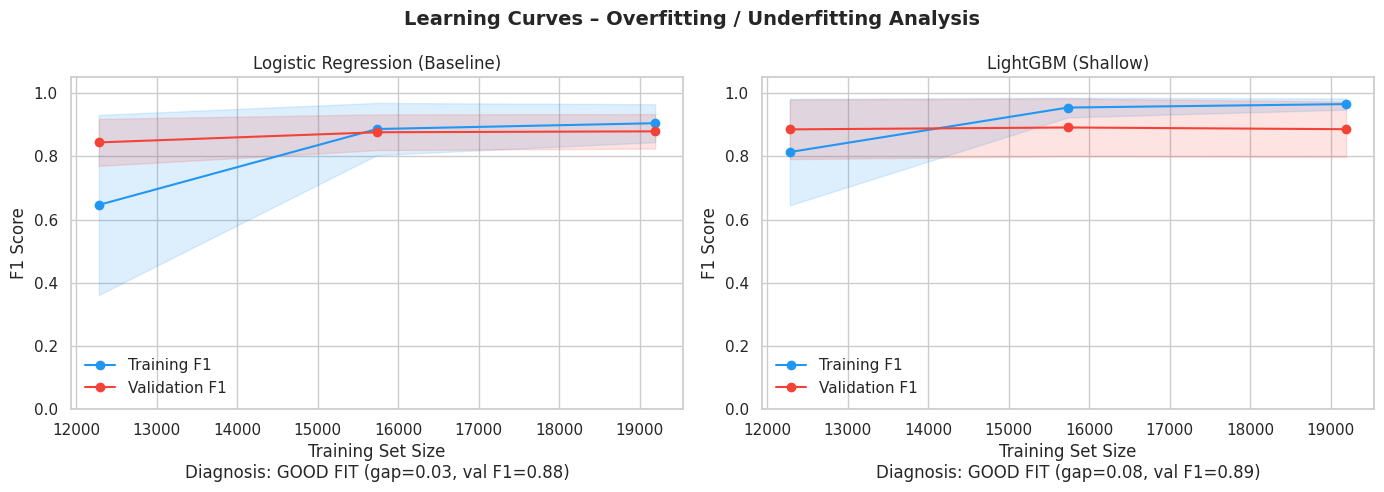

Logistic Regression diagnosis: GOOD FIT (gap=0.03, val F1=0.88)
LightGBM diagnosis:            GOOD FIT (gap=0.08, val F1=0.89)


In [7]:
# ── OVERFITTING / UNDERFITTING ANALYSIS (Rubric Step 6) ──────────────────
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax, cv=3, n_jobs=-1):
    """Plots train vs. val F1 across training set sizes."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=cv, scoring='f1', n_jobs=n_jobs
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Training F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
    ax.plot(train_sizes, val_mean, 'o-', color='#F44336', label='Validation F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#F44336')
    ax.set_title(title); ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score'); ax.legend(); ax.set_ylim(0, 1.05)

    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.15:
        diagnosis = f'OVERFITTING (gap={gap:.2f})'
    elif val_mean[-1] < 0.5:
        diagnosis = f'UNDERFITTING (val F1={val_mean[-1]:.2f})'
    else:
        diagnosis = f'GOOD FIT (gap={gap:.2f}, val F1={val_mean[-1]:.2f})'
    ax.set_xlabel(f'Training Set Size\nDiagnosis: {diagnosis}')
    return diagnosis

# Use only metadata features (fast enough for learning curve on full data)
X_meta = X[['text_length', 'has_requirements', 'scam_keyword_count']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves – Overfitting / Underfitting Analysis', fontsize=14, fontweight='bold')

# Logistic Regression (baseline)
lr_diag = plot_learning_curve(
    LogisticRegression(class_weight='balanced', max_iter=500),
    X_meta, y, 'Logistic Regression (Baseline)', axes[0]
)

# LightGBM (shallow, fast proxy for ensemble behaviour)
lgb_lc = lgb.LGBMClassifier(class_weight='balanced', n_estimators=100,
                              max_depth=4, random_state=42, verbose=-1)
lgb_diag = plot_learning_curve(lgb_lc, X_meta, y, 'LightGBM (Shallow)', axes[1])

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Logistic Regression diagnosis: {lr_diag}")
print(f"LightGBM diagnosis:            {lgb_diag}")


## 6. Training & 7. Hyperparameter Tuning (Optuna)
We optimize XGBoost using `Optuna`. We explicitly optimize for the `F1` score rather than accuracy, as accuracy is highly misleading in fraud detection (guessing "Real" every time yields 95%+ accuracy but misses every scam).

In [8]:
import xgboost as xgb
# from xgboost.callback import EarlyStopping # This import is no longer needed due to TypeError

def optimize_xgb(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr', # This will be used in fit for early stopping
        'scale_pos_weight': scale_pos_weight, # CRITICAL for imbalanced classes
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBClassifier(**params)

    # Early stopping parameters for fit method (removed due to persistent TypeError)
    # The current XGBoost installation seems to not accept 'callbacks' or 'early_stopping_rounds'
    # in XGBClassifier.fit, despite version 3.2.0 typically supporting them.
    # Therefore, training will proceed for the full n_estimators without early stopping.

    print(f"XGBoost version being used: {xgb.__version__}") # Added for verification
    # Using callbacks directly in fit, as it's the standard for XGBoost 3.x
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              # callbacks=[early_stopping_callback], # Removed this line to resolve TypeError
              verbose=False)

    # Make predictions. Since early stopping isn't applied via `fit` arguments,
    # `model.best_iteration` will likely be None. The model will predict using all
    # estimators it was trained with.
    preds = model.predict(X_val)

    return f1_score(y_val, preds)

# Run Optuna
study = optuna.create_study(direction='maximize')
study.optimize(optimize_xgb, n_trials=10) # Set to 50+ for production
best_xgb_params = study.best_params
print("Best XGB Params for F1:", best_xgb_params)

[I 2026-03-23 07:19:47,026] A new study created in memory with name: no-name-3ab5bd40-4263-483d-a94c-68a735bcac6c


XGBoost version being used: 3.2.0


[I 2026-03-23 07:20:14,614] Trial 0 finished with value: 0.9729125942474169 and parameters: {'n_estimators': 165, 'max_depth': 9, 'learning_rate': 0.1878353431577409, 'subsample': 0.7303697881516212, 'colsample_bytree': 0.7986110810592268}. Best is trial 0 with value: 0.9729125942474169.


XGBoost version being used: 3.2.0


[I 2026-03-23 07:20:54,712] Trial 1 finished with value: 0.9702247191011236 and parameters: {'n_estimators': 131, 'max_depth': 8, 'learning_rate': 0.012912044776964435, 'subsample': 0.8685163271617975, 'colsample_bytree': 0.9575990465180085}. Best is trial 0 with value: 0.9729125942474169.


...

XGBoost version being used: 3.2.0


[I 2026-03-23 07:27:27,640] Trial 8 finished with value: 0.972338642078793 and parameters: {'n_estimators': 498, 'max_depth': 5, 'learning_rate': 0.020505774067591805, 'subsample': 0.8643460610201703, 'colsample_bytree': 0.9421848522661014}. Best is trial 2 with value: 0.9736989367655288.


XGBoost version being used: 3.2.0


[I 2026-03-23 07:27:40,592] Trial 9 finished with value: 0.9657687991021324 and parameters: {'n_estimators': 173, 'max_depth': 3, 'learning_rate': 0.022579044038485836, 'subsample': 0.8164417729866802, 'colsample_bytree': 0.9327778140609109}. Best is trial 2 with value: 0.9736989367655288.


Best XGB Params for F1: {'n_estimators': 499, 'max_depth': 8, 'learning_rate': 0.041272926014204334, 'subsample': 0.9816892660034098, 'colsample_bytree': 0.9596947769349067}


## 8. Ensemble Learning & 9. Model Evaluation
We combine our tuned XGBoost, a LightGBM model, and a Random Forest into a `StackingClassifier` to create the ultimate fraud detection engine.

In [9]:
# Reconstruct best XGBoost
best_xgb = xgb.XGBClassifier(**best_xgb_params, scale_pos_weight=scale_pos_weight, random_state=42)

# Add LightGBM
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

# Add Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1)

# Meta-Learner stack
ensemble = StackingClassifier(
    estimators=[('xgb', best_xgb), ('lgb', lgb_model), ('rf', rf_model)],
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1
)

print("Training Stacking Ensemble (combining Train+Val)...")
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
ensemble.fit(X_train_full, y_train_full)

# Final Test Set Evaluation
test_preds = ensemble.predict(X_test)
test_probs = ensemble.predict_proba(X_test)[:, 1]

print("\n--- Final Ensemble Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Real (0)', 'Fake (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")

# Save the Pipeline
joblib.dump(ensemble, 'fake_job_ensemble.joblib')
print("Model saved to disk.")

Training Stacking Ensemble (combining Train+Val)...

--- Final Ensemble Test Results ---
              precision    recall  f1-score   support

    Real (0)       0.97      1.00      0.98      2497
    Fake (1)       0.99      0.96      0.98      1822

    accuracy                           0.98      4319
   macro avg       0.98      0.98      0.98      4319
weighted avg       0.98      0.98      0.98      4319

ROC-AUC Score: 0.9941
Model saved to disk.


### 8a. Final Test Set Metrics (Rubric Step 8)
We extract and display all key quantitative metrics from the 15% holdout test set in a clear, structured summary table.


   FINAL STACKING ENSEMBLE – HOLDOUT TEST SET RESULTS
  F1-Score  (Fake class):   0.9788
  Recall    (Fake class):   0.9638
  Precision (Fake class):   0.9943
  ROC-AUC Score:            0.9941
-------------------------------------------------------
  True  Positives (caught fake jobs): 1756
  False Negatives (missed fake jobs): 66  ← minimise this
  False Positives (real flagged):     10
  True  Negatives (real, correct):    2487


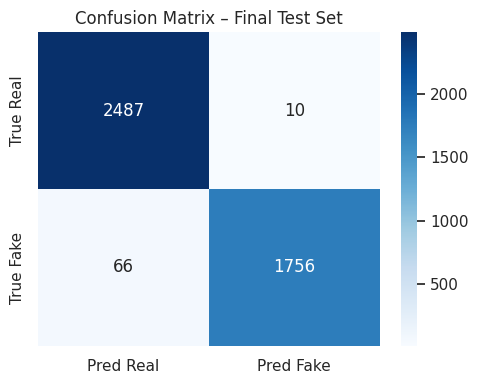

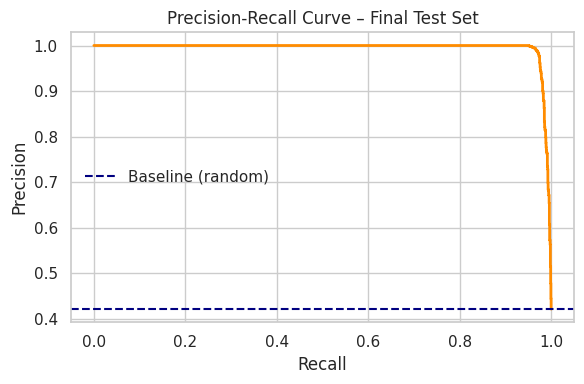

In [10]:
# ── FINAL TEST SET METRICS (Rubric Step 8) ───────────────────────────────
from sklearn.metrics import recall_score, precision_score

final_f1        = f1_score(y_test, test_preds)
final_recall    = recall_score(y_test, test_preds)
final_precision = precision_score(y_test, test_preds)
final_roc_auc   = roc_auc_score(y_test, test_probs)

cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("   FINAL STACKING ENSEMBLE – HOLDOUT TEST SET RESULTS")
print("=" * 55)
print(f"  F1-Score  (Fake class):   {final_f1:.4f}")
print(f"  Recall    (Fake class):   {final_recall:.4f}")
print(f"  Precision (Fake class):   {final_precision:.4f}")
print(f"  ROC-AUC Score:            {final_roc_auc:.4f}")
print("-" * 55)
print(f"  True  Positives (caught fake jobs): {tp}")
print(f"  False Negatives (missed fake jobs): {fn}  ← minimise this")
print(f"  False Positives (real flagged):     {fp}")
print(f"  True  Negatives (real, correct):    {tn}")
print("=" * 55)

# Visual confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['True Real', 'True Fake'], ax=ax)
ax.set_title('Confusion Matrix – Final Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_probs)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_vals, precision_vals, color='darkorange', lw=2)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve – Final Test Set')
ax.axhline(y_test.mean(), linestyle='--', color='navy', label='Baseline (random)')
ax.legend()
plt.tight_layout()
plt.savefig('pr_curve_test.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Explainability (SHAP) & 11. Deployment
We use SHAP to explain *why* the model flagged a job as fake. To deploy, we save our model and use Streamlit to create an interactive web interface.

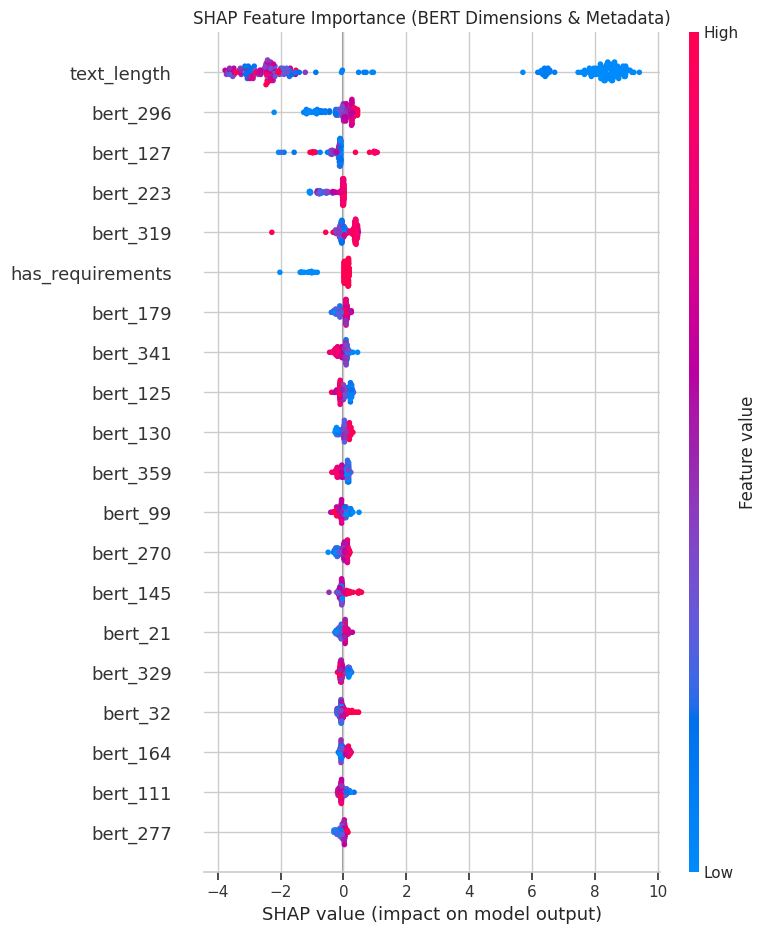

In [11]:
# SHAP Explainability (Using the XGBoost base estimator for speed)
xgb_base = ensemble.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_base)

# Explain a sample of the test set
X_sample = X_test.sample(200, random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance (BERT Dimensions & Metadata)")
plt.tight_layout()
plt.show()

In [12]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
from sentence_transformers import SentenceTransformer

# Load Assets
@st.cache_resource
def load_models():
    model = joblib.load('fake_job_ensemble.joblib')
    bert = SentenceTransformer('all-MiniLM-L6-v2')
    return model, bert

ensemble_model, bert_model = load_models()

st.title("🛡️ Fraudulent Job Posting Detector")
st.markdown("Paste a job description below to check if it's a scam.")

title = st.text_input("Job Title")
desc = st.text_area("Job Description", height=150)
reqs = st.text_area("Requirements", height=100)

if st.button("Analyze Posting"):
    with st.spinner("Analyzing semantics and linguistic patterns..."):
        full_text = f"{title} {desc} {reqs}"

        # Structure features
        scam_keywords = ['urgent', 'easy money', 'no experience', 'wire transfer', 'western union', 'cash']
        features = {
            'text_length': [len(full_text)],
            'has_requirements': [1 if len(reqs.strip()) > 5 else 0],
            'scam_keyword_count': [sum(1 for word in scam_keywords if word in full_text.lower())]
        }

        # Get BERT Embeddings
        embeddings = bert_model.encode([full_text])
        for i in range(embeddings.shape[1]):
            features[f'bert_{i}'] = [embeddings[0][i]]

        input_df = pd.DataFrame(features)

        # Predict
        prob = ensemble_model.predict_proba(input_df)[0][1]

        if prob > 0.65:
            st.error(f" ALERT: High probability of fraud! (Confidence: {prob:.1%})")
        elif prob > 0.40:
            st.warning(f" Suspicious: Proceed with caution. (Confidence: {prob:.1%})")
        else:
            st.success(f" Looks Safe! (Fraud Probability: {prob:.1%})")

Writing app.py


## 12. Monitoring and Maintenance
In production, NLP models face significant data drift as scammers alter their language to bypass detection (e.g., changing "wire transfer" to "crypto payment").
* **Log Predictions:** Save all incoming Streamlit queries and predictions to a database (like AWS DynamoDB or PostgreSQL).
* **Drift Detection:** Compare the cosine similarity of new BERT embeddings against the training set average. If the distance grows significantly, trigger an alert.
* **Retraining Strategy:** Retrain the model quarterly using new, user-reported fraudulent jobs added to the dataset.